# Data Understanding & Data Preprocessing – House Price Dataset

##Import Library

Mengimpor library yang digunakan untuk analisis data, visualisasi, dan preprocessing seperti Pandas, NumPy, Matplotlib, dan Scikit-learn.

In [ ]:
# Import library
import numpy as np
import os
import matplotlib as mpl
import matplotlib.pyplot as plt
import pandas as pd

##Load Dataset

Dataset House Price dimuat dari file CSV dan menampilkan 5 data


In [ ]:
# Load Dataset
df = pd.read_csv('/content/drive/MyDrive/MAGANG/minggu 2_proyek 1/House Price Prediction Dataset.csv')

df.head()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1,1360,5,4,3,1970,Downtown,Excellent,No,149919
1,2,4272,5,4,3,1958,Downtown,Excellent,No,424998
2,3,3592,2,2,3,1938,Downtown,Good,No,266746
3,4,966,4,2,2,1902,Suburban,Fair,Yes,244020
4,5,4926,1,4,2,1975,Downtown,Fair,Yes,636056


##Dataset Overview

Dataset terdiri dari 2000 data dan 10 variabel. Terdapat 7 fitur numerik dan 3 fitur kategorikal. Variabel Price digunakan sebagai target untuk prediksi harga rumah

In [ ]:
df.shape
df.columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Id         2000 non-null   int64 
 1   Area       2000 non-null   int64 
 2   Bedrooms   2000 non-null   int64 
 3   Bathrooms  2000 non-null   int64 
 4   Floors     2000 non-null   int64 
 5   YearBuilt  2000 non-null   int64 
 6   Location   2000 non-null   object
 7   Condition  2000 non-null   object
 8   Garage     2000 non-null   object
 9   Price      2000 non-null   int64 
dtypes: int64(7), object(3)
memory usage: 156.4+ KB


##Dataset Audit

*   Rata-rata luas rumah sekitar 2786 sqft
*   Rata-rata jumlah kamar tidur sekitar 3 kamar
*   Rata-rata kamar mandi sekitar 2–3 kamar mandi
*   Harga rumah memiliki rentang sekitar 50.000 hingga hampir 1.000.000
Hal ini menunjukkan bahwa dataset memiliki variasi karakteristik rumah yang cukup beragam.

In [ ]:
df.describe()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Price
count,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000
mean,1000.500000,2786.209500,3.003500,2.55250,1.993500,1961.446000,537676.855000
std,577.494589,1295.146799,1.424606,1.10899,0.809188,35.926695,276428.845719
min,1.000000,501.000000,1.000000,1.00000,1.000000,1900.000000,50005.000000
25%,500.750000,1653.000000,2.000000,2.00000,1.000000,1930.000000,300098.000000
50%,1000.500000,2833.000000,3.000000,3.00000,2.000000,1961.000000,539254.000000
75%,1500.250000,3887.500000,4.000000,4.00000,3.000000,1993.000000,780086.000000
max,2000.000000,4999.000000,5.000000,4.00000,3.000000,2023.000000,999656.000000


##Missing Value Analysis

Seluruh variabel memiliki nilai 0 sehingga dataset tidak memiliki data kosong

In [ ]:
df.isnull().sum()

,0
Id,0
Area,0
Bedrooms,0
Bathrooms,0
Floors,0
YearBuilt,0
Location,0
Condition,0
Garage,0
Price,0


##Distribusi Target

Histogram menunjukkan bahwa harga rumah berada pada kisaran 50.000 hingga sekitar 1.000.000.

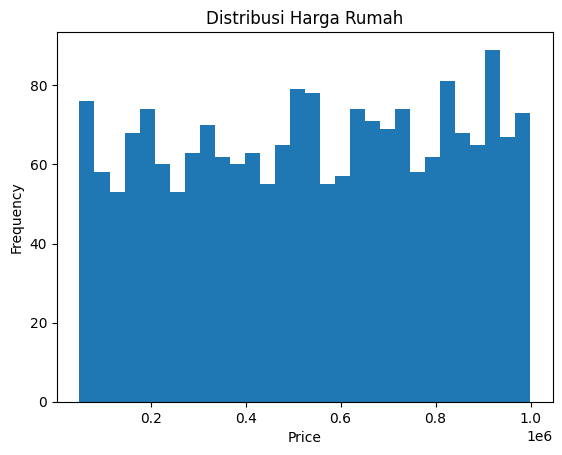

In [ ]:
plt.hist(df['Price'], bins=30)
plt.title("Distribusi Harga Rumah")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

##Data Cleaning

Data cleaning dilakukan dengan menghapus kemungkinan data duplikat dan memastikan tidak terdapat data kosong pada dataset.

In [ ]:
df.drop_duplicates(inplace=True)
df.dropna(inplace=True)

##Encoding

Variabel kategorikal seperti Location, Condition, dan Garage diubah menjadi bentuk numerik menggunakan LabelEncoder agar dapat diproses oleh model machine learning.

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['Location'] = le.fit_transform(df['Location'])
df['Condition'] = le.fit_transform(df['Condition'])
df['Garage'] = le.fit_transform(df['Garage'])

##Split Data

Dataset dibagi menjadi data training (80%) dan data testing (20%) untuk proses pelatihan dan evaluasi model.

In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop('Price', axis=1)
y = df['Price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

##Scaling

Feature scaling dilakukan menggunakan StandardScaler untuk menormalkan nilai fitur. Scaling dilakukan setelah proses split data untuk menghindari data leakage.

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)